## 1. Install dependencies

In [1]:
!pip install -q ultralytics roboflow pyyaml scikit-learn


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 37.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 285.0/285.0 kB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 88.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 128.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 5.6 MB/s eta 0:00:00


## 2. Download the dataset
Get a free API key from https://app.roboflow.com/settings/api and paste it below.

In [2]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="") # YOUR API KEY
project = rf.workspace("arfiani-nur-sayidah-9lizr").project("apple-sorting-2bfhk")
version = project.version(2)
dataset = version.download("yolo26")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Apple-Sorting-2 in yolo26:: 100%|██████████| 1399/1399 [00:00<00:00, 8046.81it/s]


## 3. Data info train / val / test

Roboflow exports usually already come split into `train/`, `valid/`, `test/` folders with a `data.yaml`.
The function below re-splits from scratch (80/10/10) in case you bring your own flat folder of
images + YOLO `.txt` labels instead.

In [4]:
import os
import yaml

DATASET_DIR = dataset.location
data_yaml_path = os.path.join(DATASET_DIR, "data.yaml")
with open(data_yaml_path) as f:
    data_cfg = yaml.safe_load(f)

print("Classes:", data_cfg["names"])
print("Train path:", data_cfg.get("train"))
print("Val path:", data_cfg.get("val"))

Classes: ['apple', 'damaged_apple']
Train path: ../train/images
Val path: ../valid/images


## 4. Train a YOLOv8 model

In [8]:
from ultralytics import YOLO

model = YOLO("yolo26n.pt")  # nano model, fast to train

results = model.train(
    data=data_yaml_path,
    epochs=50,
    imgsz=416,
    batch=16,
    patience=10,
    project="plant_detector_runs",
    name="train",
)

Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Apple-Sorting-2/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-3, nbs=64, nms=False,

## 5. Validate the model

In [10]:
best_weights = "/content/runs/detect/plant_detector_runs/train/weights/best.pt"

trained_model = YOLO(best_weights)
metrics = trained_model.val(data=data_yaml_path)

print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)
print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)

Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,375,226 parameters, 0 gradients, 5.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 814.8±212.6 MB/s, size: 15.7 KB)
val: Scanning /content/Apple-Sorting-2/valid/labels.cache... 178 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 178/178 74.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 12/12 3.4it/s 3.6s
                   all        178        723        0.6       0.68      0.656      0.424
                 apple        108        522      0.661      0.702        0.7      0.412
         damaged_apple        103        201      0.539      0.658      0.612      0.436
Speed: 2.7ms preprocess, 4.4ms inference, 0.0ms loss, 0.3ms postprocess per image
Results saved to /content/runs/detect/val-3
mAP50: 0.6559453272226674
mAP50-95: 0.4239253764612584
Precision: 0.6000317167668175
Recal

## 6. Look at training curves and sample predictions

In [11]:
from PIL import Image

results_png = "plant_detector_runs/train/results.png"
if os.path.exists(results_png):
    display(Image.open(results_png))


image 1/1 /content/Apple-Sorting-2/test/images/apple--106-_jpg.rf.e94c7574363c7c61fb5c051fa40047f0.jpg: 640x640 4 apples, 9.2ms
Speed: 2.6ms preprocess, 9.2ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 640)


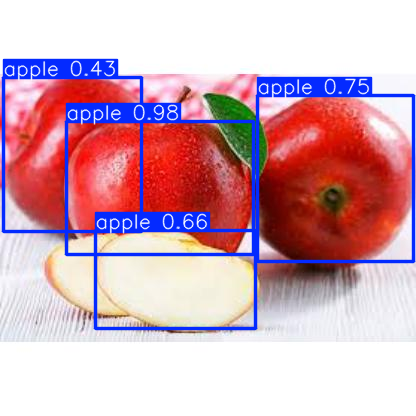


image 1/1 /content/Apple-Sorting-2/test/images/apple--119-_jpg.rf.129e3871c50316b174a5b44d44d04fdc.jpg: 640x640 1 apple, 1 damaged_apple, 14.8ms
Speed: 4.1ms preprocess, 14.8ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)


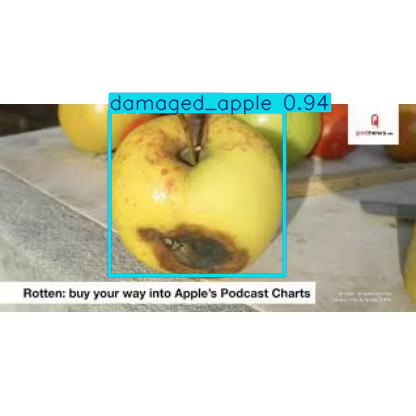


image 1/1 /content/Apple-Sorting-2/test/images/apple--178-_jpg.rf.3a1707c00a5a252791acc0c8e7cfa6b7.jpg: 640x640 5 apples, 16.5ms
Speed: 3.8ms preprocess, 16.5ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 640)


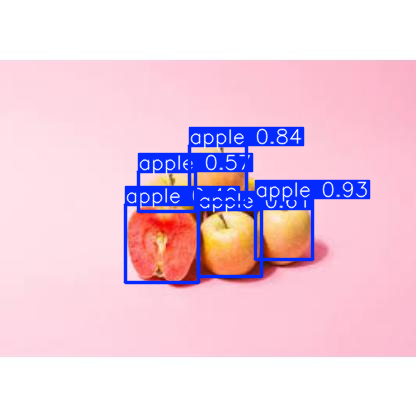


image 1/1 /content/Apple-Sorting-2/test/images/apple--148-_jpg.rf.30e312ca41461fa8aead235858f87dda.jpg: 640x640 2 apples, 6 damaged_apples, 16.6ms
Speed: 6.2ms preprocess, 16.6ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 640)


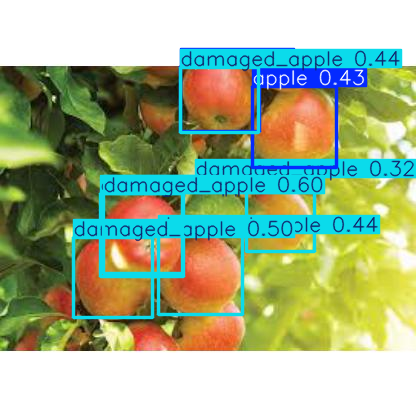


image 1/1 /content/Apple-Sorting-2/test/images/apple--127-_jpg.rf.e194acbaa16fdd5e105c6ee60eaba4ed.jpg: 640x640 1 apple, 15.7ms
Speed: 5.2ms preprocess, 15.7ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)


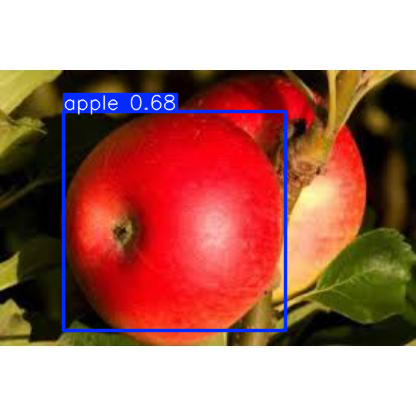

In [12]:
test_images_dir = os.path.join(DATASET_DIR, "test", "images")
if os.path.exists(test_images_dir):
    sample_files = os.listdir(test_images_dir)[:5]
    for fname in sample_files:
        img_path = os.path.join(test_images_dir, fname)
        preds = trained_model.predict(img_path, conf=0.25, save=False)
        for p in preds:
            display(Image.fromarray(p.plot()[..., ::-1]))

## 7. Export the trained weights for the app

Copy `best.pt` next to `app.py` so the Streamlit app can load it directly.

In [13]:
import shutil

shutil.copy(best_weights, "best.pt")
print("Saved best.pt to project root - ready for app.py")

Saved best.pt to project root - ready for app.py
